# # ML - 지도학습 - Timeseries Forecasting 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : 머신러닝 기법을 활용한 시계열 예측 모델 개발
- 분석 단위 : month
- 분석 변수 : 월별 승객수

[주요 실습 내용]
- Timeseries 데이터 특성 확인
- 시계열 예측에서 Target / Feature 데이타 구조
- Timeseries 데이타 파생변수 생성 : Lag 변수 등
- ML 이용한 Timeseries 예측 모델 구조

# 데이타 준비
- 분석 데이타 : Airline Passengers Dataset
- 데이타 설명 : 월별 항공 승객 수 데이타를 활용하여 미래 승객 수를 예측하기 위함
- 기간 : 1949년 1월 ~ 1960년 12월, 144개월(12년)
- 변수 설명

| 컬럼명        | 한글명     | 의미                         | 비고              |
| ---------- | ------- | -------------------------- | --------------- |
| Month      | 기준 월    | 연도-월(YYYY-MM)              | 문자형 |
| Passengers | 항공 승객 수 | 해당 월 국제선 항공 승객 수 (단위: 천 명) | Target 변수       |







데이타 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


컬럼정보 확인

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형fo()

데이타 전처리

In [3]:
# 컬럼명 변경
df.columns = ["date", "passengers"]

# 날짜형 변환
df["date"] = pd.to_datetime(df["date"])

# 날짜 기준 정렬
df = df.sort_values("date").reset_index(drop=True)
df

,date,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [4]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


# Feature Creation

- Timeseries 파생변수 생성

In [33]:
# 날짜 변수
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# 과거 Lag 변수
df["lag_1"] = df["passengers"].shift(1)     # 1개월 전
df["lag_2"] = df["passengers"].shift(2)     # 2개월 전
df["lag_3"] = df["passengers"].shift(3)     # 3개월 전
df["lag_6"] = df["passengers"].shift(6)
df["lag_12"] = df["passengers"].shift(12)   # 1년전

# 이동평균 변수
df["rolling_mean_3"] = df["passengers"].rolling(window=3).mean()        # 3개월 평균
df["rolling_mean_6"] = df["passengers"].rolling(window=6).mean()        # 6개월 평균
df["rolling_mean_12"] = df["passengers"].rolling(window=12).mean()      # 12개월 평균

# 파생변수 미생성건 제거
df_model = df.dropna().reset_index(drop=True)
df_model

,date,passengers,year,month,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,lag_6
0,1950-01-01,115,1950,1,118.0,104.0,119.0,112.0,112.333333,123.333333,126.916667,148.0
1,1950-02-01,126,1950,2,115.0,118.0,104.0,118.0,119.666667,119.666667,127.583333,148.0
2,1950-03-01,141,1950,3,126.0,115.0,118.0,132.0,127.333333,120.500000,128.333333,136.0
3,1950-04-01,135,1950,4,141.0,126.0,115.0,129.0,134.000000,123.166667,128.833333,119.0
4,1950-05-01,125,1950,5,135.0,141.0,126.0,121.0,133.666667,126.666667,129.166667,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...
127,1960-08-01,606,1960,8,622.0,535.0,472.0,559.0,587.666667,519.166667,463.333333,391.0
128,1960-09-01,508,1960,9,606.0,622.0,535.0,463.0,578.666667,534.000000,467.083333,419.0
129,1960-10-01,461,1960,10,508.0,606.0,622.0,407.0,525.000000,534.000000,471.583333,461.0
130,1960-11-01,390,1960,11,461.0,508.0,606.0,362.0,453.000000,520.333333,473.916667,472.0


# Target 설정

In [26]:
# 예측 기간
look_after = 3

# Target 설정: 다음 월(t+1) 승객 수
df_model["target"] = df_model["passengers"].shift(look_after*(-1))

# Target 미생성건 제거
df_model = df_model.dropna().reset_index(drop=True)
df_model

,date,passengers,year,month,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,target
0,1950-01-01,115,1950,1,118.0,104.0,119.0,112.0,112.333333,123.333333,126.916667,135.0
1,1950-02-01,126,1950,2,115.0,118.0,104.0,118.0,119.666667,119.666667,127.583333,125.0
2,1950-03-01,141,1950,3,126.0,115.0,118.0,132.0,127.333333,120.500000,128.333333,149.0
3,1950-04-01,135,1950,4,141.0,126.0,115.0,129.0,134.000000,123.166667,128.833333,170.0
4,1950-05-01,125,1950,5,135.0,141.0,126.0,121.0,133.666667,126.666667,129.166667,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...
120,1960-01-01,417,1960,1,405.0,362.0,407.0,360.0,394.666667,435.500000,433.083333,461.0
121,1960-02-01,391,1960,2,417.0,405.0,362.0,342.0,404.333333,407.500000,437.166667,472.0
122,1960-03-01,419,1960,3,391.0,417.0,405.0,406.0,409.000000,400.166667,438.250000,535.0
123,1960-04-01,461,1960,4,419.0,391.0,417.0,396.0,423.666667,409.166667,443.666667,622.0


# 데이타 분할

Data Partition
- 목적 : 모델이 학습에 사용하지 않은 새로운 데이터에서도 잘 동작하는지 검증하기 위함
 - 시간 순서를 유지하여 과거 데이터로 학습 하고 (Train), 미래 데이터로 평가 (Test)
- Train Set : 모델 학습용, Test Set : 모델 평가용
- 데이타 변환시 변환 통계량은 Train 데이터에서 계산하고, Test 데이터에는 그 기준을 적용해야 함 (Data Leakage 문제)

In [27]:
# 마지막 2년을 테스트셋으로 사용
train = df_model.iloc[:-24]
test = df_model.iloc[-24:]

X, y 분리

In [28]:
# train
y_train  = train['target']
X_train  = train.drop(columns=['target', 'date'])

# test
y_test   = test['target']
X_test   = test.drop(columns=['target', 'date'])

# Feature Transformation

Scaling
   - Min-Max Scaling

In [29]:
from sklearn.preprocessing import MinMaxScaler

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Min-Max Scaling
scaler = MinMaxScaler()

# Train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

 # Test
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Random Forest
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

학습 및 예측

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 모델 정의
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 평가
print("\n=== RandomForest === ")
print(f"Train MAPE : {mean_absolute_percentage_error(y_train, train_pred) * 100:.2f}%")
print(f"Test  MAPE : {mean_absolute_percentage_error(y_test, test_pred) * 100:.2f}%")


=== RandomForest === 
Train MAPE : 4.50%
Test  MAPE : 11.19%


- Feature Importance

           Feature  Importance
0       passengers    0.509307
9  rolling_mean_12    0.178554
6           lag_12    0.172380
7   rolling_mean_3    0.055204
1             year    0.031938
8   rolling_mean_6    0.016581
4            lag_2    0.012281
2            month    0.010581
5            lag_3    0.007615
3            lag_1    0.005560


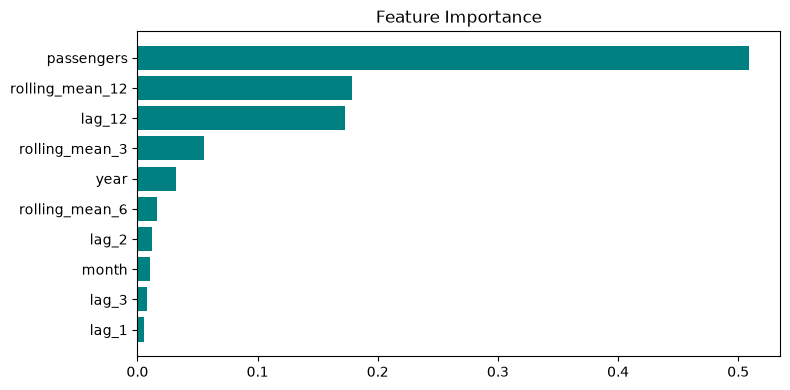

In [13]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

- 원래 데이터에 예측값 병합하기

In [14]:
# Test Set 에 예측값 병합하기
result = test[["date", "passengers", "target"]].copy()
result["prediction_t_plus_1"] = test_pred

result = result.rename(columns={
    "date": "current_month",
    "passengers": "current_passengers",
    "target": "actual_next_month"
})

result

,current_month,current_passengers,actual_next_month,prediction_t_plus_1
107,1958-12-01,337,360.0,341.414997
108,1959-01-01,360,342.0,351.293785
109,1959-02-01,342,406.0,361.355079
110,1959-03-01,406,396.0,403.974630
111,1959-04-01,396,420.0,385.874844
112,1959-05-01,420,472.0,432.415605
113,1959-06-01,472,548.0,458.316464
114,1959-07-01,548,559.0,438.086798
115,1959-08-01,559,463.0,426.830250
116,1959-09-01,463,407.0,409.351833


- 실측값 vs 예측값 시각화

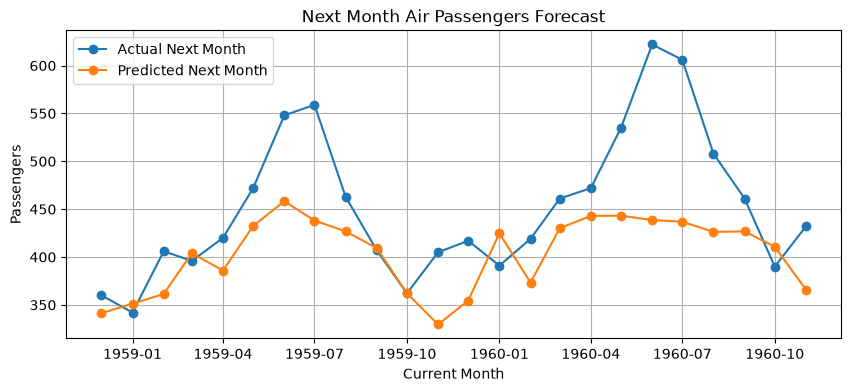

In [15]:
# Test Set 기준 실측값 vs 예측값 시각화
plt.figure(figsize=(10, 4))

plt.plot(
    result["current_month"],
    result["actual_next_month"],
    marker="o",
    label="Actual Next Month"
)

plt.plot(
    result["current_month"],
    result["prediction_t_plus_1"],
    marker="o",
    label="Predicted Next Month"
)

plt.title("Next Month Air Passengers Forecast")
plt.xlabel("Current Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

### [Self-Practice]
Q1) 다른 ML 모델들을 적용해서 모델 성능을 비교해 보세요. 예시) LinearRegression, XGBRegressor, LGBMRegressor 등  
Q2) 성능이 가장 좋은 모델로 Test 예측값을 생성하고, 시각화를 통해 예측값과 실측값을 비교해 보세요.  
Q3) 성능이 가장 좋은 모델기준으로 시계열 파생변수를 추가하거나 제거하면서 모델 성능을 비교하세요.   
Q4) 성능이 가장 좋은 모델기준으로 다음 달 (t+1) 예측이 아니라 더 먼 미래 (t+3), (t+5)를 예측하는 모델을 생성하고, 각 예측기간별 모델 성능을 비교해 보세요.   

## Q1

### LinearRegression

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 7.236
Test  MAPE: 6.548


### XGBRegressor

In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 0.022
Test  MAPE: 11.163


### LGBMRegressor

In [20]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = LGBMRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1      # 로그 출력 안 함
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 4.162
Test  MAPE: 13.985


## Q2

In [30]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 0.013
Test  MAPE: 8.837


In [31]:
# Test Set 에 예측값 병합하기
result = test[["date", "passengers", "target"]].copy()
result["prediction_t_plus_1"] = test_pred

result = result.rename(columns={
    "date": "current_month",
    "passengers": "current_passengers",
    "target": "actual_next_month"
})

result

,current_month,current_passengers,actual_next_month,prediction_t_plus_1
101,1958-06-01,435,404.0,451.394775
102,1958-07-01,491,359.0,377.827911
103,1958-08-01,505,310.0,378.040009
104,1958-09-01,404,337.0,399.738831
105,1958-10-01,359,360.0,400.814636
106,1958-11-01,310,342.0,400.948456
107,1958-12-01,337,406.0,401.686798
108,1959-01-01,360,396.0,414.976074
109,1959-02-01,342,420.0,413.464355
110,1959-03-01,406,472.0,445.336914


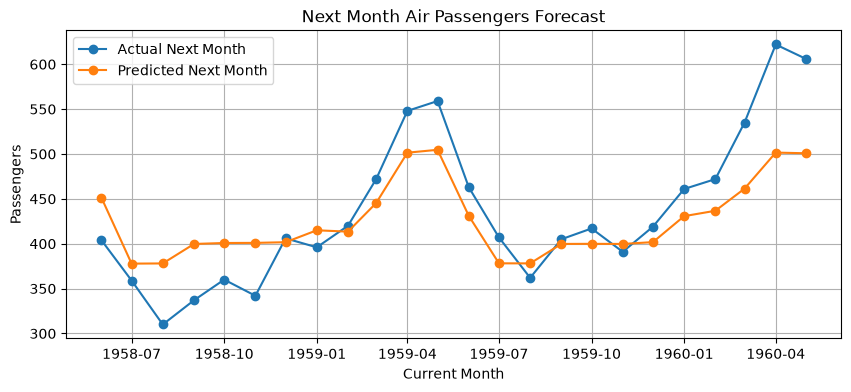

In [32]:
# Test Set 기준 실측값 vs 예측값 시각화
plt.figure(figsize=(10, 4))

plt.plot(
    result["current_month"],
    result["actual_next_month"],
    marker="o",
    label="Actual Next Month"
)

plt.plot(
    result["current_month"],
    result["prediction_t_plus_1"],
    marker="o",
    label="Predicted Next Month"
)

plt.title("Next Month Air Passengers Forecast")
plt.xlabel("Current Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()